In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from scipy import stats

NOTEBOOK_DIR = Path.cwd().resolve()
candidates = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
REPO_ROOT = next(
    (path for path in candidates if (path / "jsw/강원_재_EDA/re_eda_common.py").exists()),
    Path(r"D:/farm-system-public-02"),
)
MODULE_DIR = REPO_ROOT / "jsw/강원_재_EDA"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from re_eda_common import (
    DATA_PATHS,
    RAW_WEATHER_COLUMNS,
    check_sources,
    configure_notebook,
    frame_inventory,
    load_canadian_indices,
    load_dem_metadata,
    load_grid_bundle,
    load_hourly_weather,
)

configure_notebook()

REPO_ROOT: D:\farm-system-public-02
matplotlib font.family: ['Malgun Gothic']


## 1. 원천 파일 존재 여부

In [2]:
SOURCE_KEYS = ['weather_cells', 'weather_grid', 'weather_hourly_raw', 'climate_type', 'canada_ffmc', 'canada_fwi', 'dem']
source_audit = check_sources(SOURCE_KEYS)
display(source_audit)

,데이터키,존재,크기_MB,경로
0,weather_cells,True,0.05,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
1,weather_grid,True,0.09,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
2,weather_hourly_raw,True,106.98,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
3,climate_type,True,0.00,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
4,canada_ffmc,True,6.75,D:\farm-system-public-02\data\학습데이터\캐나다_FFMC_선...
5,canada_fwi,True,10.10,D:\farm-system-public-02\data\학습데이터\캐나다_FWI_일단...
6,dem,True,9.47,D:\farm-system-public-02\data\강원도_데이터\강원도_공간데이...


## 2. 기상셀, 기후지형유형, 공간격자 로딩

In [3]:
grid_bundle = load_grid_bundle()
weather_cells = grid_bundle["cells"]
climate_type = grid_bundle["climate"]
weather_grid = grid_bundle["grid"]

display(weather_cells.head())
display(climate_type["기후지형유형"].value_counts(dropna=False))
print("기상 격자 CRS:", weather_grid.crs)

,기상셀ID,셀ID,기후권역,대표관측망,대표지점번호,대표지점명,면적_km2,중심X_5186,중심Y_5186,중심경도_wgs84,중심위도_wgs84,영역WKT_wgs84
0,YD_0001,YD_0001,영동,ASOS,105,강릉,134.467293,367778.425131,569785.112496,128.902714,37.712422,"POLYGON ((128.875749 37.629264, 128.827104 37...."
1,YD_0002,YD_0002,영동,ASOS,90,속초,102.982315,331807.869122,630148.837915,128.506006,38.261948,"POLYGON ((128.540533 38.209315, 128.435959 38...."
2,YD_0003,YD_0003,영동,ASOS,106,동해,60.417467,385679.625075,547421.764901,129.099934,37.507617,"POLYGON ((129.062243 37.444466, 129.080675 37...."
3,YD_0004,YD_0004,영동,AWS,521,강현,39.694215,338601.941682,615714.148931,128.580793,38.130934,"POLYGON ((128.531506 38.09035, 128.563885 38.1..."
4,YD_0005,YD_0005,영동,AWS,517,간성,177.032843,325342.618059,640768.390574,128.434040,38.358513,"MULTIPOLYGON (((128.414002 38.274111, 128.4128..."


기후지형유형
영서 내륙형    44
고지·산간형    27
영동 해안형    21
Name: count, dtype: int64

기상 격자 CRS: EPSG:4326


## 3. 원본 시간단위 기상 로딩

In [4]:
hourly_weather = load_hourly_weather(
    derived=False,
    columns=RAW_WEATHER_COLUMNS,
)
print("기간:", hourly_weather["일시"].min(), "~", hourly_weather["일시"].max())
print("기상셀 수:", hourly_weather["기상셀ID"].nunique())
display(hourly_weather.head())

기간: 2020-01-01 00:00:00 ~ 2021-12-31 23:00:00
기상셀 수: 92


,기상셀ID,일시,기온_C,풍속_m_s,풍향_deg,강수량_mm,현지기압_hPa,해면기압_hPa,습도_pct
0,YD_0001,2020-01-01 00:00:00,-4.18,4.52,226.26,0.0,999.82,1021.12,29.00
1,YD_0001,2020-01-01 01:00:00,-3.59,4.28,235.90,0.0,999.68,1020.90,40.85
2,YD_0001,2020-01-01 02:00:00,-2.97,4.01,243.05,0.0,999.70,1020.91,44.09
3,YD_0001,2020-01-01 03:00:00,-2.79,4.89,233.54,0.0,999.58,1020.75,50.15
4,YD_0001,2020-01-01 04:00:00,-2.54,4.32,245.21,0.0,999.42,1020.55,52.23


## 4. 캐나다 산불위험지수 로딩

In [5]:
canadian_indices = load_canadian_indices()
print("기간:", canadian_indices["날짜"].min(), "~", canadian_indices["날짜"].max())
print("기상셀 수:", canadian_indices["기상셀ID"].nunique())
display(canadian_indices.head())

기간: 2020-01-01 00:00:00 ~ 2021-12-31 00:00:00
기상셀 수: 92


,기상셀ID,날짜,기온_C,습도_pct,풍속_km_h,강수량_mm,FFMC,FFMC_10일평균,Indexed_FFMC,FFMC_논문식_발생확률,FFMC_FWI산출,DMC,DC,ISI,BUI,FWI
0,YD_0001,2020-01-01,4.25,38.03,13.536,0.0,86.204666,86.204666,4,0.761151,86.204666,6.408158,15.4690,4.929736,6.391844,4.223833
1,YD_0001,2020-01-02,5.33,42.30,15.588,0.0,86.319667,86.262167,4,0.761151,86.319667,6.864910,16.1324,5.556121,6.836046,4.952625
2,YD_0001,2020-01-03,7.11,29.71,14.076,0.0,88.156553,86.893629,4,0.761151,88.156553,7.575354,17.1162,6.688864,7.528072,6.226062
3,YD_0001,2020-01-04,7.15,30.08,14.544,0.0,88.736902,87.354447,4,0.761151,88.736902,8.285502,18.1072,7.443182,8.222515,7.166616
4,YD_0001,2020-01-05,7.52,35.58,4.176,0.0,88.785842,87.640726,4,0.761151,88.785842,8.969132,19.1648,4.445448,8.895435,4.509274


## 5. DEM 메타데이터 로딩

In [6]:
dem_metadata = load_dem_metadata()
display(dem_metadata)

{'path': 'D:\\farm-system-public-02\\data\\강원도_데이터\\강원도_공간데이터\\강원도_DEM_데이터.tif',
 'crs': 'PROJCS["Transverse Mercator",GEOGCS["GRS80 ELLIPSOID",DATUM["GRS80 ELLIPSOID",SPHEROID["GRS 1980",6378137,298.257222101004],TOWGS84[0,0,0,0,0,0,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38.0000000000001],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]',
 'width': 2243,
 'height': 1948,
 'count': 1,
 'dtype': 'float32',
 'nodata': -9999.0,
 'bounds': (208276.0, 493523.0, 410146.0, 668843.0),
 'resolution': (90.0, 90.0)}

## 로딩 결과 요약

In [7]:
loaded_frames = {
    "weather_cells": weather_cells,
    "climate_type": climate_type,
    "weather_grid": weather_grid,
    "hourly_weather": hourly_weather,
    "canadian_indices": canadian_indices,
}
display(frame_inventory(loaded_frames))

,이름,행,열,메모리_MB,CRS
0,weather_cells,92,12,0.05,NaN
1,climate_type,92,3,0.00,NaN
2,weather_grid,92,12,0.01,EPSG:4326
3,hourly_weather,1614048,9,121.80,NaN
4,canadian_indices,67252,16,8.66,NaN


## 6. S1-01 출력 경로

In [8]:
OUTPUT_ROOT = MODULE_DIR / "outputs/Step1"
TABLE_DIR = OUTPUT_ROOT / "tables"
PLOT_DIR = OUTPUT_ROOT / "plots"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

source_audit.to_csv(TABLE_DIR / "S1-01_source_audit.csv", index=False, encoding="utf-8-sig")
print("TABLE_DIR:", TABLE_DIR)
print("PLOT_DIR:", PLOT_DIR)

TABLE_DIR: D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step1\tables
PLOT_DIR: D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step1\plots


## 7. S1-01 모집단·키·기간 감사

In [9]:
CELL_KEY = "기상셀ID"
meta_cell_set = set(weather_cells[CELL_KEY].dropna())

def audit_dataset(name, frame, key_columns, time_column=None, expected_rows=None):
    frame_cell_set = set(frame[CELL_KEY].dropna())
    return {
        "데이터셋": name,
        "행수": len(frame),
        "예상행수": expected_rows,
        "행완전성_pct": 100 * len(frame) / expected_rows if expected_rows else np.nan,
        "기상셀수": frame[CELL_KEY].nunique(dropna=True),
        "중복키수": int(frame[key_columns].duplicated().sum()),
        "결측키행수": int(frame[key_columns].isna().any(axis=1).sum()),
        "메타에는있고자료에는없는셀수": len(meta_cell_set - frame_cell_set),
        "자료에만있는셀수": len(frame_cell_set - meta_cell_set),
        "시작": frame[time_column].min() if time_column else pd.NaT,
        "종료": frame[time_column].max() if time_column else pd.NaT,
    }

hourly_start = hourly_weather["일시"].min()
hourly_end = hourly_weather["일시"].max()
expected_hours_per_cell = len(pd.date_range(hourly_start, hourly_end, freq="h"))
canadian_start = canadian_indices["날짜"].min()
canadian_end = canadian_indices["날짜"].max()
expected_days_per_cell = len(pd.date_range(canadian_start, canadian_end, freq="D"))

dataset_audit = pd.DataFrame([
    audit_dataset("기상셀 메타", weather_cells, [CELL_KEY], expected_rows=len(meta_cell_set)),
    audit_dataset("기후지형유형", climate_type, [CELL_KEY], expected_rows=len(meta_cell_set)),
    audit_dataset("기상 격자", weather_grid, [CELL_KEY], expected_rows=len(meta_cell_set)),
    audit_dataset(
        "시간기상",
        hourly_weather,
        [CELL_KEY, "일시"],
        time_column="일시",
        expected_rows=len(meta_cell_set) * expected_hours_per_cell,
    ),
    audit_dataset(
        "캐나다 지수",
        canadian_indices,
        [CELL_KEY, "날짜"],
        time_column="날짜",
        expected_rows=len(meta_cell_set) * expected_days_per_cell,
    ),
])

hourly_cell_coverage = (
    hourly_weather.groupby(CELL_KEY, as_index=False)
    .agg(
        시작=("일시", "min"),
        종료=("일시", "max"),
        행수=("일시", "size"),
        고유시각수=("일시", "nunique"),
    )
)
hourly_cell_coverage["예상시간수"] = expected_hours_per_cell
hourly_cell_coverage["누락시간수"] = expected_hours_per_cell - hourly_cell_coverage["고유시각수"]
hourly_cell_coverage["완전성_pct"] = 100 * hourly_cell_coverage["고유시각수"] / expected_hours_per_cell

canadian_cell_coverage = (
    canadian_indices.groupby(CELL_KEY, as_index=False)
    .agg(
        시작=("날짜", "min"),
        종료=("날짜", "max"),
        행수=("날짜", "size"),
        고유날짜수=("날짜", "nunique"),
    )
)
canadian_cell_coverage["예상날짜수"] = expected_days_per_cell
canadian_cell_coverage["누락날짜수"] = expected_days_per_cell - canadian_cell_coverage["고유날짜수"]
canadian_cell_coverage["완전성_pct"] = 100 * canadian_cell_coverage["고유날짜수"] / expected_days_per_cell

dataset_audit.to_csv(TABLE_DIR / "S1-01_dataset_audit.csv", index=False, encoding="utf-8-sig")
hourly_cell_coverage.to_csv(TABLE_DIR / "S1-01_hourly_cell_coverage.csv", index=False, encoding="utf-8-sig")
canadian_cell_coverage.to_csv(TABLE_DIR / "S1-01_canadian_cell_coverage.csv", index=False, encoding="utf-8-sig")

display(dataset_audit)
display(hourly_cell_coverage.describe(include="all").T)

,데이터셋,행수,예상행수,행완전성_pct,기상셀수,중복키수,결측키행수,메타에는있고자료에는없는셀수,자료에만있는셀수,시작,종료
0,기상셀 메타,92,92,100.0,92,0,0,0,0,NaT,NaT
1,기후지형유형,92,92,100.0,92,0,0,0,0,NaT,NaT
2,기상 격자,92,92,100.0,92,0,0,0,0,NaT,NaT
3,시간기상,1614048,1614048,100.0,92,0,0,0,0,2020-01-01,2021-12-31 23:00:00
4,캐나다 지수,67252,67252,100.0,92,0,0,0,0,2020-01-01,2021-12-31 00:00:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
기상셀ID,92,92,YD_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
시작,92,NaN,NaN,NaN,2020-01-01 00:00:00,2020-01-01 00:00:00,2020-01-01 00:00:00,2020-01-01 00:00:00,2020-01-01 00:00:00,2020-01-01 00:00:00,NaN
종료,92,NaN,NaN,NaN,2021-12-31 23:00:00,2021-12-31 23:00:00,2021-12-31 23:00:00,2021-12-31 23:00:00,2021-12-31 23:00:00,2021-12-31 23:00:00,NaN
행수,92.0,NaN,NaN,NaN,17544.0,17544.0,17544.0,17544.0,17544.0,17544.0,0.0
고유시각수,92.0,NaN,NaN,NaN,17544.0,17544.0,17544.0,17544.0,17544.0,17544.0,0.0
예상시간수,92.0,NaN,NaN,NaN,17544.0,17544.0,17544.0,17544.0,17544.0,17544.0,0.0
누락시간수,92.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
완전성_pct,92.0,NaN,NaN,NaN,100.0,100.0,100.0,100.0,100.0,100.0,0.0


## 8. S1-01 결측 감사

In [10]:
missingness_records = []
for dataset_name, frame in {
    "기상셀 메타": weather_cells,
    "기후지형유형": climate_type,
    "시간기상": hourly_weather,
    "캐나다 지수": canadian_indices,
}.items():
    for column in frame.columns:
        if column == "geometry":
            continue
        missing_count = int(frame[column].isna().sum())
        missingness_records.append({
            "데이터셋": dataset_name,
            "변수": column,
            "행수": len(frame),
            "결측수": missing_count,
            "결측률_pct": 100 * missing_count / len(frame),
        })

missingness = pd.DataFrame(missingness_records)
missingness.to_csv(TABLE_DIR / "S1-01_missingness.csv", index=False, encoding="utf-8-sig")
display(missingness.sort_values(["결측률_pct", "데이터셋", "변수"], ascending=[False, True, True]))

,데이터셋,변수,행수,결측수,결측률_pct
0,기상셀 메타,기상셀ID,92,0,0.0
2,기상셀 메타,기후권역,92,0,0.0
3,기상셀 메타,대표관측망,92,0,0.0
5,기상셀 메타,대표지점명,92,0,0.0
4,기상셀 메타,대표지점번호,92,0,0.0
6,기상셀 메타,면적_km2,92,0,0.0
1,기상셀 메타,셀ID,92,0,0.0
11,기상셀 메타,영역WKT_wgs84,92,0,0.0
7,기상셀 메타,중심X_5186,92,0,0.0
8,기상셀 메타,중심Y_5186,92,0,0.0


## 9. S1-01 기상셀 중심점과 DEM 샘플링 감사

In [11]:
cell_points_wgs84 = gpd.GeoDataFrame(
    weather_cells[[CELL_KEY, "기후권역", "중심경도_wgs84", "중심위도_wgs84"]].copy(),
    geometry=gpd.points_from_xy(
        weather_cells["중심경도_wgs84"],
        weather_cells["중심위도_wgs84"],
    ),
    crs="EPSG:4326",
)
polygon_by_cell = weather_grid.set_index(CELL_KEY).geometry
cell_points_wgs84["중심점_셀내부"] = [
    bool(polygon_by_cell.loc[cell_id].covers(point))
    for cell_id, point in zip(cell_points_wgs84[CELL_KEY], cell_points_wgs84.geometry)
]

with rasterio.open(DATA_PATHS["dem"]) as dem:
    dem_crs = dem.crs
    dem_bounds = dem.bounds
    dem_nodata = dem.nodata
    cell_points_dem = cell_points_wgs84.to_crs(dem_crs)
    xy = [(point.x, point.y) for point in cell_points_dem.geometry]
    sampled = []
    inside_bounds = []
    for x_coord, y_coord in xy:
        is_inside = (
            dem_bounds.left <= x_coord <= dem_bounds.right
            and dem_bounds.bottom <= y_coord <= dem_bounds.top
        )
        inside_bounds.append(is_inside)
        value = next(dem.sample([(x_coord, y_coord)], masked=True))[0]
        sampled.append(np.nan if np.ma.is_masked(value) else float(value))

cell_points_dem["DEM_X"] = cell_points_dem.geometry.x
cell_points_dem["DEM_Y"] = cell_points_dem.geometry.y
cell_points_dem["DEM_범위내"] = inside_bounds
cell_points_dem["DEM_고도_m"] = sampled
cell_points_dem["DEM_샘플성공"] = (
    cell_points_dem["DEM_범위내"]
    & cell_points_dem["DEM_고도_m"].notna()
    & (cell_points_dem["DEM_고도_m"] != dem_nodata)
)

dem_samples = cell_points_dem.drop(columns="geometry").copy()
dem_summary = pd.DataFrame({
    "지표": [
        "전체 기상셀 수",
        "중심점 셀 내부 수",
        "DEM 범위 내 수",
        "DEM 유효 표본 수",
        "DEM 표본 성공률_pct",
        "DEM 최소 고도_m",
        "DEM 중앙 고도_m",
        "DEM 최대 고도_m",
    ],
    "값": [
        len(cell_points_dem),
        int(cell_points_wgs84["중심점_셀내부"].sum()),
        int(cell_points_dem["DEM_범위내"].sum()),
        int(cell_points_dem["DEM_샘플성공"].sum()),
        100 * cell_points_dem["DEM_샘플성공"].mean(),
        cell_points_dem["DEM_고도_m"].min(),
        cell_points_dem["DEM_고도_m"].median(),
        cell_points_dem["DEM_고도_m"].max(),
    ],
})

dem_samples.to_csv(TABLE_DIR / "S1-01_dem_samples.csv", index=False, encoding="utf-8-sig")
dem_summary.to_csv(TABLE_DIR / "S1-01_dem_summary.csv", index=False, encoding="utf-8-sig")
display(dem_summary)
display(dem_samples.head())

,지표,값
0,전체 기상셀 수,92.000000
1,중심점 셀 내부 수,92.000000
2,DEM 범위 내 수,92.000000
3,DEM 유효 표본 수,92.000000
4,DEM 표본 성공률_pct,100.000000
5,DEM 최소 고도_m,2.545508
6,DEM 중앙 고도_m,334.034195
7,DEM 최대 고도_m,1197.044312


,기상셀ID,기후권역,중심경도_wgs84,중심위도_wgs84,중심점_셀내부,DEM_X,DEM_Y,DEM_범위내,DEM_고도_m,DEM_샘플성공
0,YD_0001,영동,128.902714,37.712422,True,367778.425131,569785.112496,True,38.398575,True
1,YD_0002,영동,128.506006,38.261948,True,331807.869122,630148.837915,True,61.493595,True
2,YD_0003,영동,129.099934,37.507617,True,385679.625075,547421.764901,True,81.152412,True
3,YD_0004,영동,128.580793,38.130934,True,338601.941682,615714.148931,True,45.542442,True
4,YD_0005,영동,128.434040,38.358513,True,325342.618059,640768.390574,True,79.080040,True


## 10. S1-01 기상셀·DEM 표본 위치 플롯

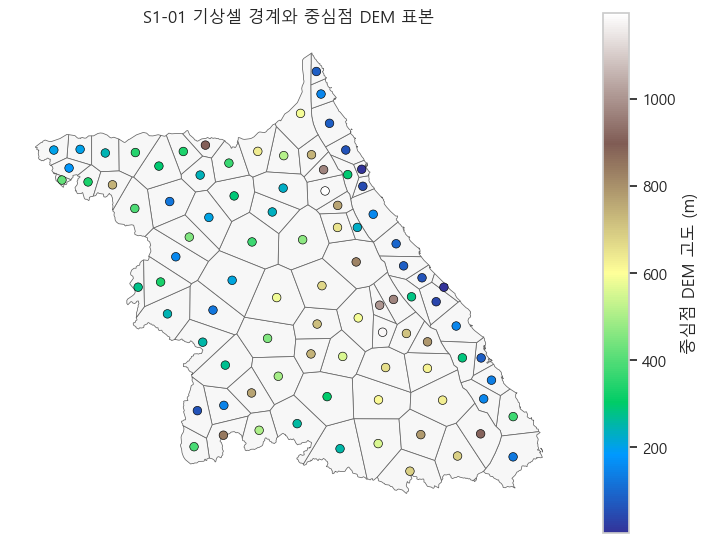

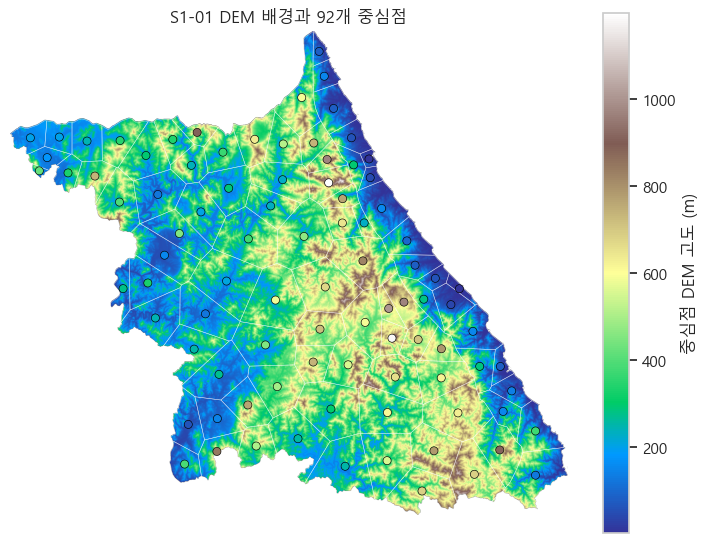

In [12]:
grid_dem = weather_grid.to_crs(dem_crs)
elevation_min = cell_points_dem["DEM_고도_m"].min()
elevation_max = cell_points_dem["DEM_고도_m"].max()
elevation_norm = Normalize(elevation_min, elevation_max)
elevation_cmap = plt.get_cmap("terrain")

fig, ax = plt.subplots(figsize=(9, 9))
grid_dem.plot(ax=ax, facecolor="#f7f7f7", edgecolor="#666666", linewidth=0.55)
ax.scatter(
    cell_points_dem.geometry.x,
    cell_points_dem.geometry.y,
    c=cell_points_dem["DEM_고도_m"],
    cmap=elevation_cmap,
    norm=elevation_norm,
    s=38,
    edgecolor="black",
    linewidth=0.45,
    zorder=3,
)
ax.set_title("S1-01 기상셀 경계와 중심점 DEM 표본")
ax.set_axis_off()
fig.colorbar(
    plt.cm.ScalarMappable(norm=elevation_norm, cmap=elevation_cmap),
    ax=ax,
    shrink=0.75,
    label="중심점 DEM 고도 (m)",
)
cell_map_path = PLOT_DIR / "S1-01_cell_center_sampling_map.png"
fig.savefig(cell_map_path, dpi=180, bbox_inches="tight")
plt.show()

with rasterio.open(DATA_PATHS["dem"]) as dem:
    dem_image = dem.read(1, masked=True)
    dem_extent = [dem.bounds.left, dem.bounds.right, dem.bounds.bottom, dem.bounds.top]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(dem_image, cmap="terrain", extent=dem_extent, origin="upper")
grid_dem.boundary.plot(ax=ax, color="white", linewidth=0.35, alpha=0.65)
ax.scatter(
    cell_points_dem.geometry.x,
    cell_points_dem.geometry.y,
    c=cell_points_dem["DEM_고도_m"],
    cmap=elevation_cmap,
    norm=elevation_norm,
    s=34,
    edgecolor="black",
    linewidth=0.45,
    zorder=3,
)
ax.set_title("S1-01 DEM 배경과 92개 중심점")
ax.set_axis_off()
fig.colorbar(
    plt.cm.ScalarMappable(norm=elevation_norm, cmap=elevation_cmap),
    ax=ax,
    shrink=0.75,
    label="중심점 DEM 고도 (m)",
)
dem_map_path = PLOT_DIR / "S1-01_dem_sampling_map.png"
fig.savefig(dem_map_path, dpi=180, bbox_inches="tight")
plt.show()

## 11. S1-01 월별 시간·날짜 완전성 플롯

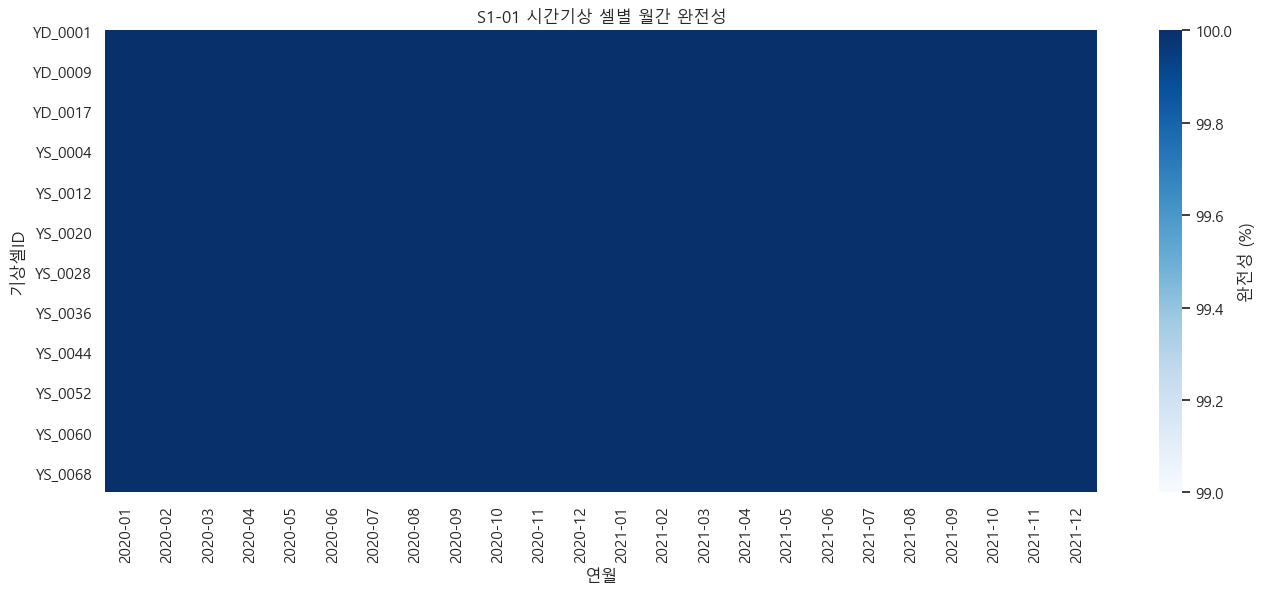

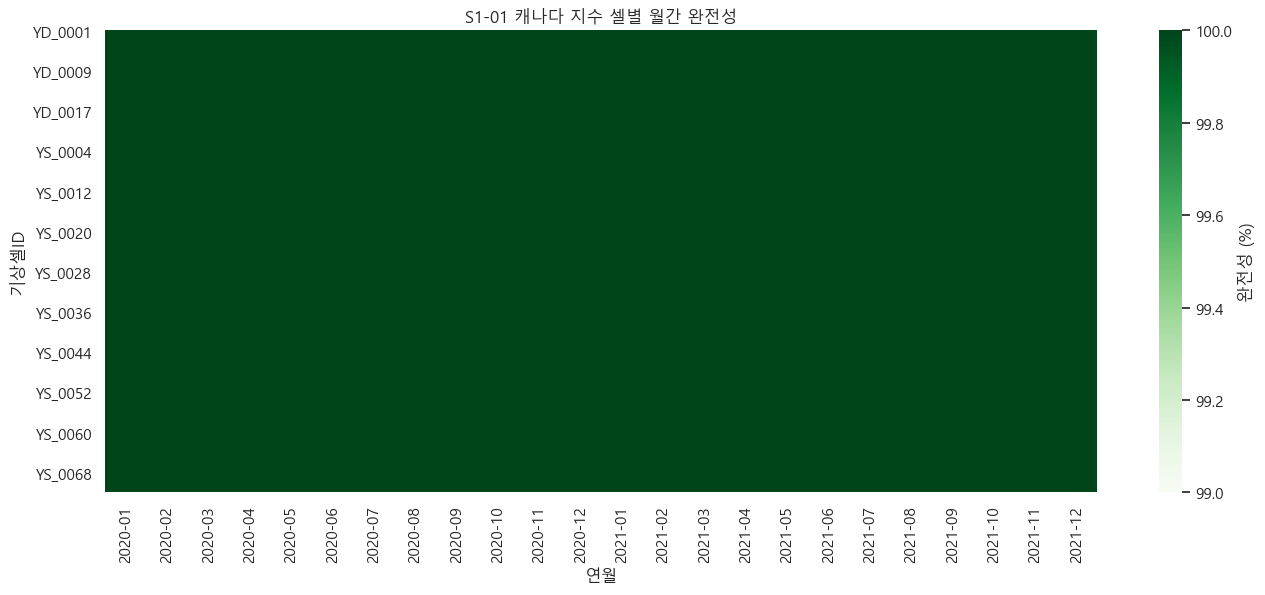

In [13]:
hourly_month = hourly_weather["일시"].dt.to_period("M")
hourly_monthly = (
    hourly_weather.assign(연월=hourly_month)
    .groupby([CELL_KEY, "연월"], as_index=False)
    .size()
)
hourly_monthly["예상수"] = hourly_monthly["연월"].dt.days_in_month * 24
hourly_monthly["완전성_pct"] = 100 * hourly_monthly["size"] / hourly_monthly["예상수"]

canadian_month = canadian_indices["날짜"].dt.to_period("M")
canadian_monthly = (
    canadian_indices.assign(연월=canadian_month)
    .groupby([CELL_KEY, "연월"], as_index=False)
    .size()
)
canadian_monthly["예상수"] = canadian_monthly["연월"].dt.days_in_month
canadian_monthly["완전성_pct"] = (
    100 * canadian_monthly["size"] / canadian_monthly["예상수"]
)

hourly_matrix = hourly_monthly.pivot(
    index=CELL_KEY, columns="연월", values="완전성_pct"
)
canadian_matrix = canadian_monthly.pivot(
    index=CELL_KEY, columns="연월", values="완전성_pct"
)
hourly_matrix.columns = hourly_matrix.columns.astype(str)
canadian_matrix.columns = canadian_matrix.columns.astype(str)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    hourly_matrix,
    ax=ax,
    cmap="Blues",
    vmin=99,
    vmax=100,
    yticklabels=8,
    cbar_kws={"label": "완전성 (%)"},
)
ax.set_title("S1-01 시간기상 셀별 월간 완전성")
ax.set_xlabel("연월")
ax.tick_params(axis="x", labelrotation=90)
hourly_completeness_path = PLOT_DIR / "S1-01_hourly_completeness_heatmap.png"
fig.savefig(hourly_completeness_path, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    canadian_matrix,
    ax=ax,
    cmap="Greens",
    vmin=99,
    vmax=100,
    yticklabels=8,
    cbar_kws={"label": "완전성 (%)"},
)
ax.set_title("S1-01 캐나다 지수 셀별 월간 완전성")
ax.set_xlabel("연월")
ax.tick_params(axis="x", labelrotation=90)
canadian_completeness_path = (
    PLOT_DIR / "S1-01_canadian_completeness_heatmap.png"
)
fig.savefig(canadian_completeness_path, dpi=180, bbox_inches="tight")
plt.show()

## 12. S1-01 완료 검증

In [14]:
summary_metrics = pd.DataFrame({
    "지표": [
        "기상셀 수",
        "시간기상 행수",
        "셀당 예상 시간수",
        "시간기상 중복 키 수",
        "시간기상 누락 시간 수",
        "시간기상 변수 결측 수",
        "캐나다 지수 행수",
        "셀당 예상 날짜수",
        "캐나다 지수 중복 키 수",
        "캐나다 지수 누락 날짜 수",
        "캐나다 지수 변수 결측 수",
        "중심점 셀 외부 수",
        "DEM 샘플 실패 수",
    ],
    "값": [
        len(meta_cell_set),
        len(hourly_weather),
        expected_hours_per_cell,
        int(hourly_weather[[CELL_KEY, "일시"]].duplicated().sum()),
        int(hourly_cell_coverage["누락시간수"].sum()),
        int(hourly_weather.isna().sum().sum()),
        len(canadian_indices),
        expected_days_per_cell,
        int(canadian_indices[[CELL_KEY, "날짜"]].duplicated().sum()),
        int(canadian_cell_coverage["누락날짜수"].sum()),
        int(canadian_indices.isna().sum().sum()),
        int((~cell_points_wgs84["중심점_셀내부"]).sum()),
        int((~cell_points_dem["DEM_샘플성공"]).sum()),
    ],
})
summary_metrics.to_csv(
    TABLE_DIR / "S1-01_summary_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

assert source_audit["존재"].all()
assert dataset_audit["중복키수"].sum() == 0
assert dataset_audit["결측키행수"].sum() == 0
assert dataset_audit["메타에는있고자료에는없는셀수"].sum() == 0
assert dataset_audit["자료에만있는셀수"].sum() == 0
assert hourly_cell_coverage["누락시간수"].sum() == 0
assert canadian_cell_coverage["누락날짜수"].sum() == 0
assert hourly_weather.isna().sum().sum() == 0
assert canadian_indices.isna().sum().sum() == 0
assert cell_points_wgs84["중심점_셀내부"].all()
assert cell_points_dem["DEM_샘플성공"].all()
for path in [
    cell_map_path,
    dem_map_path,
    hourly_completeness_path,
    canadian_completeness_path,
]:
    assert path.exists() and path.stat().st_size > 0

display(summary_metrics)
print("S1-01 validation passed")

,지표,값
0,기상셀 수,92
1,시간기상 행수,1614048
2,셀당 예상 시간수,17544
3,시간기상 중복 키 수,0
4,시간기상 누락 시간 수,0
5,시간기상 변수 결측 수,0
6,캐나다 지수 행수,67252
7,셀당 예상 날짜수,731
8,캐나다 지수 중복 키 수,0
9,캐나다 지수 누락 날짜 수,0


S1-01 validation passed


## 13. S1-02 셀별 기후 요약

In [15]:
REGION_ORDER = ["영동", "영서"]
REGION_PALETTE = {"영동": "#E45756", "영서": "#4C78A8"}

daily_background = (
    hourly_weather.assign(날짜=hourly_weather["일시"].dt.normalize())
    .groupby([CELL_KEY, "날짜"], as_index=False)
    .agg(
        평균기온_C=("기온_C", "mean"),
        일최저기온_C=("기온_C", "min"),
        일최고기온_C=("기온_C", "max"),
        평균습도_pct=("습도_pct", "mean"),
        평균풍속_m_s=("풍속_m_s", "mean"),
        일최대풍속_m_s=("풍속_m_s", "max"),
        일강수량_mm=("강수량_mm", "sum"),
    )
)
daily_background["일교차_C"] = daily_background["일최고기온_C"] - daily_background["일최저기온_C"]

analysis_years = hourly_weather["일시"].dt.year.nunique()
cell_climate = (
    daily_background.groupby(CELL_KEY, as_index=False)
    .agg(
        관측일수=("날짜", "nunique"),
        평균기온_C=("평균기온_C", "mean"),
        평균_일최저기온_C=("일최저기온_C", "mean"),
        평균_일최고기온_C=("일최고기온_C", "mean"),
        평균_일교차_C=("일교차_C", "mean"),
        평균습도_pct=("평균습도_pct", "mean"),
        평균풍속_m_s=("평균풍속_m_s", "mean"),
        평균_일최대풍속_m_s=("일최대풍속_m_s", "mean"),
        총강수량_mm=("일강수량_mm", "sum"),
    )
)
cell_climate["연평균강수량_mm"] = cell_climate["총강수량_mm"] / analysis_years
cell_climate = (
    cell_climate
    .merge(
        weather_cells[[CELL_KEY, "기후권역", "대표지점명", "중심경도_wgs84", "중심위도_wgs84"]],
        on=CELL_KEY,
        how="left",
        validate="one_to_one",
    )
    .merge(
        dem_samples[[CELL_KEY, "DEM_고도_m"]],
        on=CELL_KEY,
        how="left",
        validate="one_to_one",
    )
)
cell_climate["기후권역"] = pd.Categorical(cell_climate["기후권역"], categories=REGION_ORDER, ordered=True)

VARIABLE_SPECS = [
    ("DEM_고도_m", "DEM 고도", "m"),
    ("평균기온_C", "평균기온", "°C"),
    ("평균_일최저기온_C", "일최저기온 평균", "°C"),
    ("평균_일최고기온_C", "일최고기온 평균", "°C"),
    ("평균_일교차_C", "일교차 평균", "°C"),
    ("평균습도_pct", "평균습도", "%"),
    ("평균풍속_m_s", "평균풍속", "m/s"),
    ("평균_일최대풍속_m_s", "일최대풍속 평균", "m/s"),
    ("연평균강수량_mm", "연평균강수량", "mm/year"),
]
VARIABLE_LABELS = {column: label for column, label, _ in VARIABLE_SPECS}
ANALYSIS_COLUMNS = [column for column, _, _ in VARIABLE_SPECS]

cell_climate.to_csv(TABLE_DIR / "S1-02_cell_climate_summary.csv", index=False, encoding="utf-8-sig")
display(cell_climate.groupby("기후권역", observed=True).size().rename("셀수").reset_index())
display(cell_climate.head())

,기후권역,셀수
0,영동,21
1,영서,71


,기상셀ID,관측일수,평균기온_C,평균_일최저기온_C,평균_일최고기온_C,평균_일교차_C,평균습도_pct,평균풍속_m_s,평균_일최대풍속_m_s,총강수량_mm,연평균강수량_mm,기후권역,대표지점명,중심경도_wgs84,중심위도_wgs84,DEM_고도_m
0,YD_0001,731,12.940401,9.297880,17.018263,7.720383,65.932715,2.302246,3.675691,2983.75,1491.875,영동,강릉,128.902714,37.712422,38.398575
1,YD_0002,731,11.256943,7.922189,14.826908,6.904720,67.275567,2.994943,4.533776,4225.15,2112.575,영동,속초,128.506006,38.261948,61.493595
2,YD_0003,731,13.194922,9.899152,16.642189,6.743037,65.236235,2.135393,4.140793,2476.56,1238.280,영동,동해,129.099934,37.507617,81.152412
3,YD_0004,731,12.436011,8.574528,16.500328,7.925800,64.936941,2.180498,3.972777,3696.89,1848.445,영동,강현,128.580793,38.130934,45.542442
4,YD_0005,731,11.325835,7.671382,15.186443,7.515062,69.713002,2.601015,4.115622,4183.50,2091.750,영동,간성,128.434040,38.358513,79.080040


## 14. S1-02 기술통계와 독립표본 검정

In [16]:
def cohen_d_independent(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    pooled_sd = np.sqrt(
        ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
        / (len(a) + len(b) - 2)
    )
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan

def cliffs_delta(a, b):
    a = pd.Series(a).dropna().to_numpy(dtype=float)
    b = pd.Series(b).dropna().to_numpy(dtype=float)
    return np.sign(a[:, None] - b[None, :]).sum() / (len(a) * len(b))

def fdr_bh(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted_ranked = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted

descriptive_records = []
test_records = []
for column, label, unit in VARIABLE_SPECS:
    for region in REGION_ORDER:
        values = cell_climate.loc[cell_climate["기후권역"] == region, column].dropna().astype(float)
        descriptive_records.append({
            "변수": column,
            "표시명": label,
            "단위": unit,
            "기후권역": region,
            "N_셀": len(values),
            "평균": values.mean(),
            "표준편차": values.std(ddof=1),
            "최솟값": values.min(),
            "Q1": values.quantile(0.25),
            "중앙값": values.median(),
            "Q3": values.quantile(0.75),
            "최댓값": values.max(),
        })

    yd = cell_climate.loc[cell_climate["기후권역"] == "영동", column].dropna().astype(float)
    ys = cell_climate.loc[cell_climate["기후권역"] == "영서", column].dropna().astype(float)
    welch = stats.ttest_ind(yd, ys, equal_var=False)
    mann_whitney = stats.mannwhitneyu(yd, ys, alternative="two-sided")
    test_records.append({
        "변수": column,
        "표시명": label,
        "단위": unit,
        "영동_N셀": len(yd),
        "영서_N셀": len(ys),
        "영동_평균": yd.mean(),
        "영서_평균": ys.mean(),
        "영동_중앙값": yd.median(),
        "영서_중앙값": ys.median(),
        "평균차_영동_minus_영서": yd.mean() - ys.mean(),
        "Welch_t": welch.statistic,
        "Welch_p": welch.pvalue,
        "MannWhitney_U": mann_whitney.statistic,
        "MannWhitney_p": mann_whitney.pvalue,
        "Cohen_d_영동_minus_영서": cohen_d_independent(yd, ys),
        "Cliff_delta_영동_minus_영서": cliffs_delta(yd, ys),
    })

descriptive_stats = pd.DataFrame(descriptive_records)
region_tests = pd.DataFrame(test_records)
region_tests["Welch_q_FDR"] = fdr_bh(region_tests["Welch_p"])
region_tests["MannWhitney_q_FDR"] = fdr_bh(region_tests["MannWhitney_p"])
region_tests["Welch_FDR_0.05"] = region_tests["Welch_q_FDR"] < 0.05
region_tests["MannWhitney_FDR_0.05"] = region_tests["MannWhitney_q_FDR"] < 0.05

descriptive_stats.to_csv(TABLE_DIR / "S1-02_descriptive_stats.csv", index=False, encoding="utf-8-sig")
region_tests.to_csv(TABLE_DIR / "S1-02_region_tests.csv", index=False, encoding="utf-8-sig")
display(descriptive_stats)
display(region_tests)

,변수,표시명,단위,기후권역,N_셀,평균,표준편차,최솟값,Q1,중앙값,Q3,최댓값
0,DEM_고도_m,DEM 고도,m,영동,21,129.329141,100.719166,2.545508,61.493595,91.378746,148.892395,371.788025
1,DEM_고도_m,DEM 고도,m,영서,71,502.146036,272.237872,59.987766,253.952744,468.401001,696.860626,1197.044312
2,평균기온_C,평균기온,°C,영동,21,12.529596,0.764839,10.901387,12.023689,12.662717,13.088760,13.632141
3,평균기온_C,평균기온,°C,영서,71,9.906582,1.703650,-0.566983,9.214797,10.266125,10.766442,12.600425
4,평균_일최저기온_C,일최저기온 평균,°C,영동,21,8.833455,0.815898,7.467319,8.339713,8.740561,9.297880,10.471436
5,평균_일최저기온_C,일최저기온 평균,°C,영서,71,5.287415,1.342188,-1.178468,4.375622,5.400780,5.998311,8.251792
6,평균_일최고기온_C,일최고기온 평균,°C,영동,21,16.505721,0.919950,14.826908,16.090068,16.500328,17.018263,17.900082
7,평균_일최고기온_C,일최고기온 평균,°C,영서,71,15.337273,2.589050,0.156060,14.472633,16.148988,17.073646,18.163269
8,평균_일교차_C,일교차 평균,°C,영동,21,7.672266,0.818830,5.618632,7.425212,7.646772,7.996252,9.442353
9,평균_일교차_C,일교차 평균,°C,영서,71,10.049858,2.058662,1.334528,9.317620,10.657114,11.137244,12.631792


,변수,표시명,단위,영동_N셀,영서_N셀,영동_평균,영서_평균,영동_중앙값,영서_중앙값,평균차_영동_minus_영서,Welch_t,Welch_p,MannWhitney_U,MannWhitney_p,Cohen_d_영동_minus_영서,Cliff_delta_영동_minus_영서,Welch_q_FDR,MannWhitney_q_FDR,Welch_FDR_0.05,MannWhitney_FDR_0.05
0,DEM_고도_m,DEM 고도,m,21,71,129.329141,502.146036,91.378746,468.401001,-372.816895,-9.540871,4.065079e-15,122.0,6.807751e-09,-1.523313,-0.836351,1.219524e-14,2.042325e-08,True,True
1,평균기온_C,평균기온,°C,21,71,12.529596,9.906582,12.662717,10.266125,2.623014,10.004849,1.771667e-15,1445.0,7.893987e-11,1.697598,0.938296,7.972503e-15,3.552294e-10,True,True
2,평균_일최저기온_C,일최저기온 평균,°C,21,71,8.833455,5.287415,8.740561,5.400780,3.546040,14.843318,7.526148e-21,1483.0,7.076060e-12,2.849099,0.989269,6.773533e-20,6.368454e-11,True,True
3,평균_일최고기온_C,일최고기온 평균,°C,21,71,16.505721,15.337273,16.500328,16.148988,1.168448,3.183517,2.018820e-03,965.0,4.162024e-02,0.502743,0.294433,2.595625e-03,4.162024e-02,True,True
4,평균_일교차_C,일교차 평균,°C,21,71,7.672266,10.049858,7.646772,10.657114,-2.377592,-7.854965,1.316480e-11,233.0,1.907389e-06,-1.280928,-0.687458,2.962079e-11,4.291625e-06,True,True
5,평균습도_pct,평균습도,%,21,71,67.837284,72.971795,67.601645,73.340166,-5.134512,-5.098106,1.223871e-05,253.0,4.718217e-06,-1.221684,-0.660630,2.202969e-05,8.492791e-06,True,True
6,평균풍속_m_s,평균풍속,m/s,21,71,2.271843,1.791457,2.180498,1.534225,0.480386,3.356084,1.413288e-03,1135.0,2.960166e-04,0.634686,0.522468,2.119932e-03,3.805928e-04,True,True
7,평균_일최대풍속_m_s,일최대풍속 평균,m/s,21,71,4.014313,3.632224,3.972777,3.429439,0.382089,2.135163,3.649664e-02,1007.0,1.518184e-02,0.382823,0.350771,3.649664e-02,1.707957e-02,True,True
8,연평균강수량_mm,연평균강수량,mm/year,21,71,1608.296905,1383.110211,1501.065000,1313.245000,225.186693,2.431029,2.109761e-02,1155.0,1.419098e-04,0.632600,0.549296,2.373481e-02,2.128646e-04,True,True


## 15. S1-02 영동·영서 공간 분포와 DEM

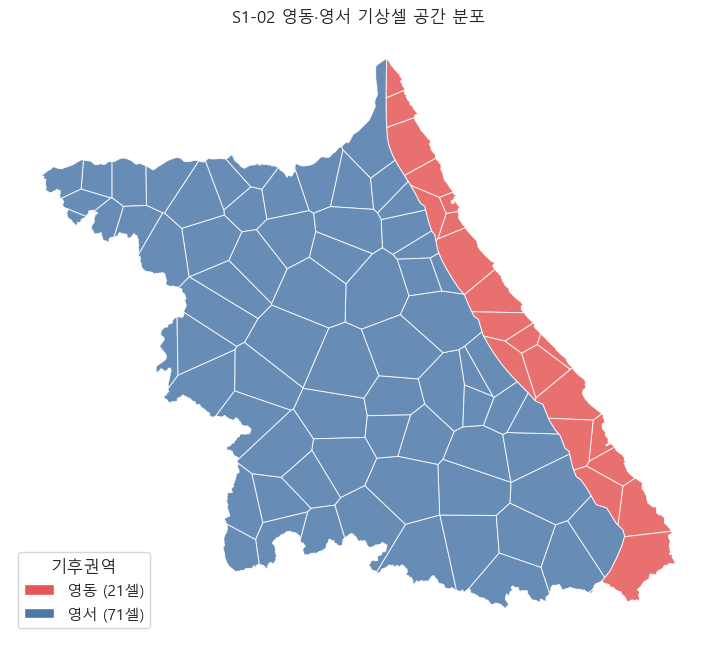

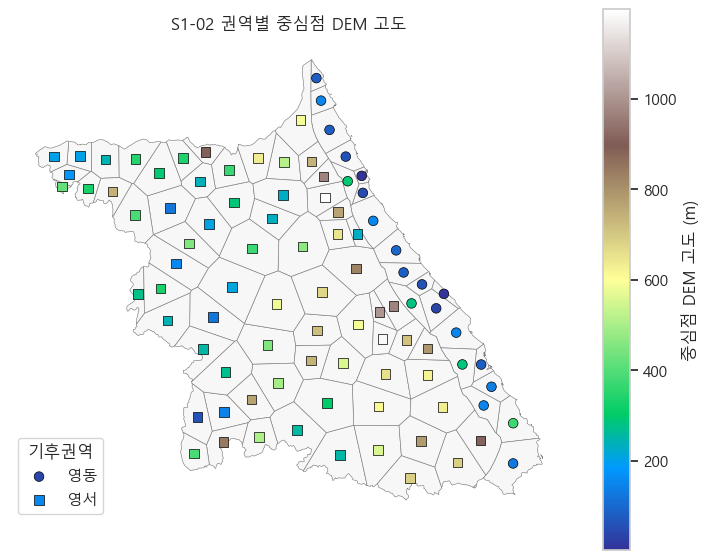

In [17]:
grid_region = weather_grid.merge(
    cell_climate[[CELL_KEY, "DEM_고도_m"]],
    on=CELL_KEY,
    how="left",
    validate="one_to_one",
).to_crs(dem_crs)
points_region = gpd.GeoDataFrame(
    cell_climate.copy(),
    geometry=gpd.points_from_xy(
        cell_climate["중심경도_wgs84"],
        cell_climate["중심위도_wgs84"],
    ),
    crs="EPSG:4326",
).to_crs(dem_crs)

fig, ax = plt.subplots(figsize=(9, 9))
for region in REGION_ORDER:
    subset = grid_region.loc[grid_region["기후권역"] == region]
    subset.plot(
        ax=ax,
        facecolor=REGION_PALETTE[region],
        edgecolor="white",
        linewidth=0.7,
        alpha=0.85,
    )
region_handles = [
    Patch(
        facecolor=REGION_PALETTE[region],
        edgecolor="white",
        label=f"{region} ({int((cell_climate['기후권역'] == region).sum())}셀)",
    )
    for region in REGION_ORDER
]
ax.legend(handles=region_handles, title="기후권역", loc="lower left")
ax.set_title("S1-02 영동·영서 기상셀 공간 분포")
ax.set_axis_off()
s102_region_map_path = PLOT_DIR / "S1-02_region_map.png"
fig.savefig(s102_region_map_path, dpi=180, bbox_inches="tight")
plt.show()

elevation_norm_s102 = Normalize(
    cell_climate["DEM_고도_m"].min(),
    cell_climate["DEM_고도_m"].max(),
)
elevation_cmap_s102 = plt.get_cmap("terrain")
fig, ax = plt.subplots(figsize=(9, 9))
grid_region.plot(ax=ax, facecolor="#f7f7f7", edgecolor="#808080", linewidth=0.45)
for region, marker in zip(REGION_ORDER, ["o", "s"]):
    subset = points_region.loc[points_region["기후권역"] == region]
    ax.scatter(
        subset.geometry.x,
        subset.geometry.y,
        c=subset["DEM_고도_m"],
        cmap=elevation_cmap_s102,
        norm=elevation_norm_s102,
        marker=marker,
        s=48,
        edgecolor="black",
        linewidth=0.5,
        label=region,
        zorder=3,
    )
ax.legend(title="기후권역", loc="lower left")
ax.set_title("S1-02 권역별 중심점 DEM 고도")
ax.set_axis_off()
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=elevation_norm_s102,
        cmap=elevation_cmap_s102,
    ),
    ax=ax,
    shrink=0.78,
    label="중심점 DEM 고도 (m)",
)
s102_dem_map_path = PLOT_DIR / "S1-02_region_dem_points.png"
fig.savefig(s102_dem_map_path, dpi=180, bbox_inches="tight")
plt.show()

## 16. S1-02 셀별 분포 boxplot

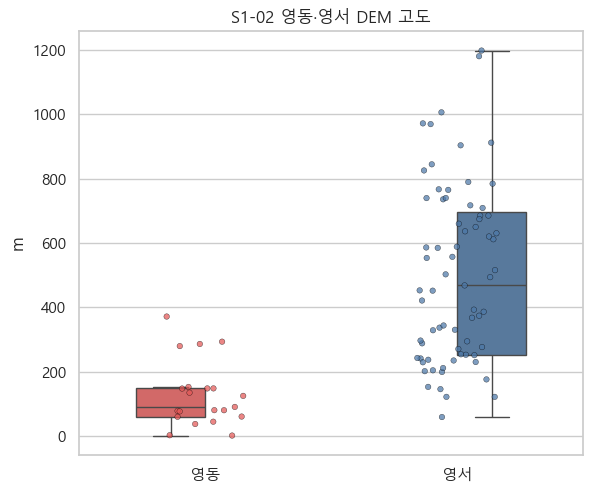

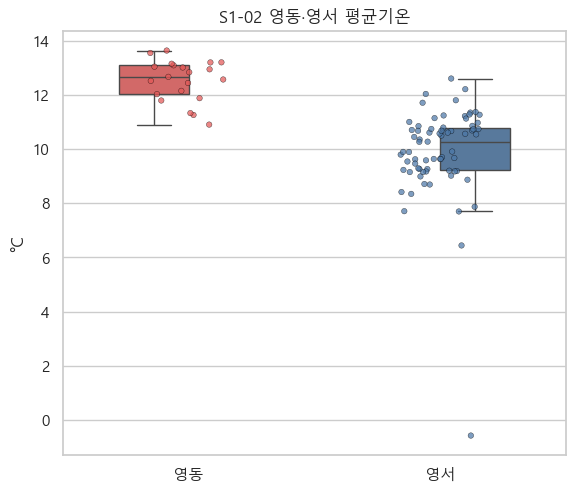

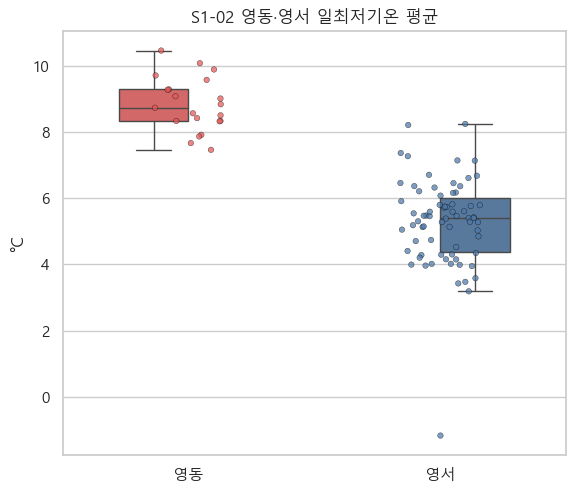

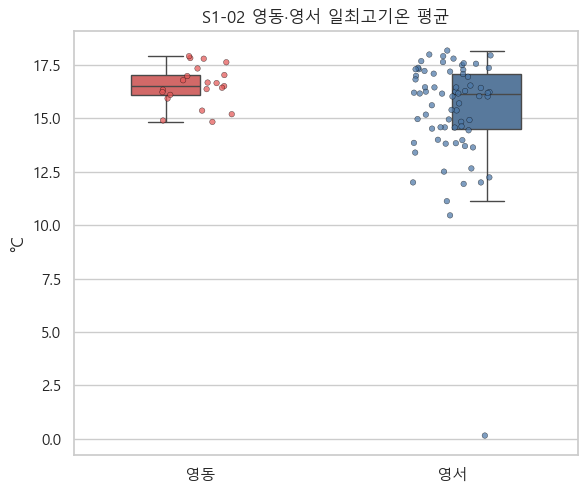

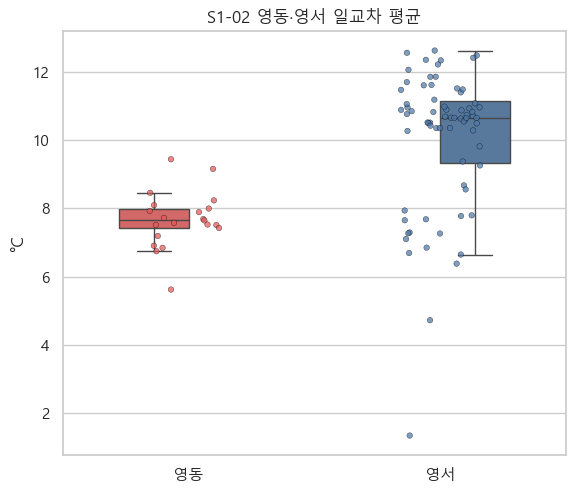

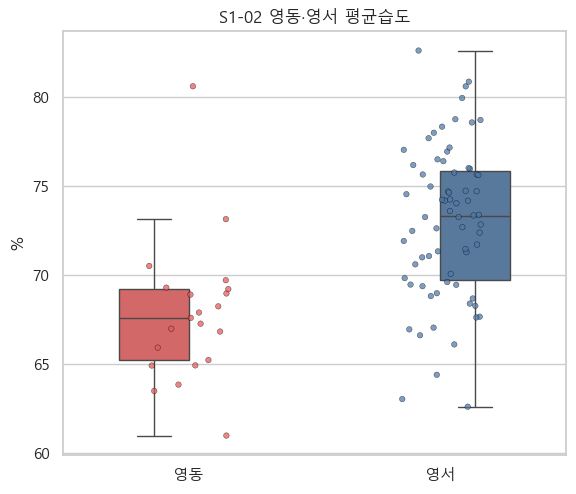

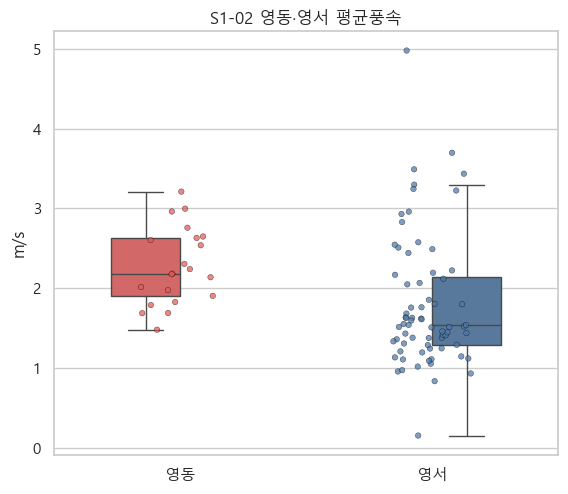

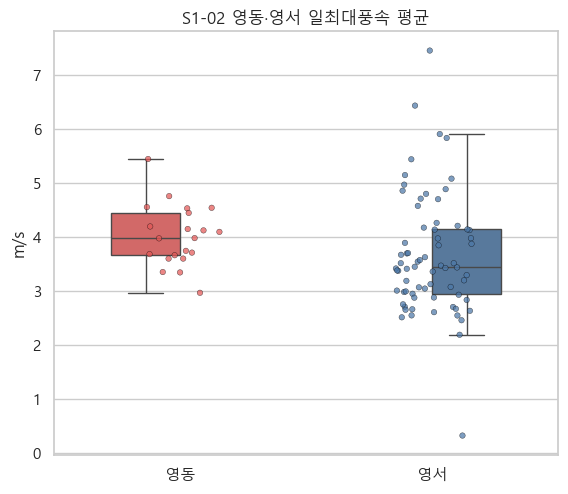

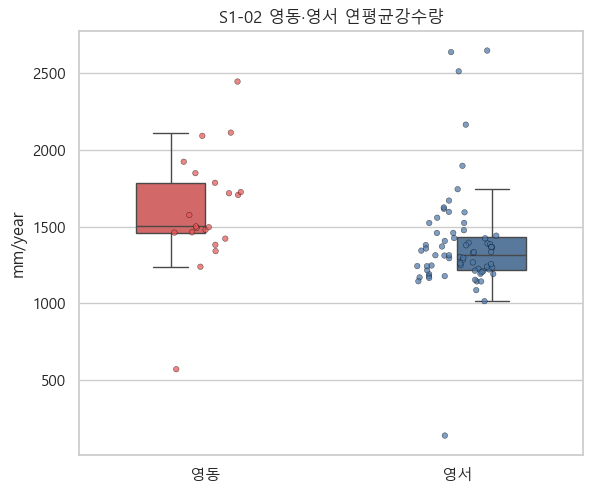

In [18]:
np.random.seed(42)
s102_box_paths = []
for column, label, unit in VARIABLE_SPECS:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.boxplot(
        data=cell_climate,
        x="기후권역",
        y=column,
        order=REGION_ORDER,
        hue="기후권역",
        palette=REGION_PALETTE,
        legend=False,
        width=0.55,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=cell_climate,
        x="기후권역",
        y=column,
        order=REGION_ORDER,
        hue="기후권역",
        palette=REGION_PALETTE,
        legend=False,
        jitter=0.16,
        size=4,
        alpha=0.72,
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
    )
    ax.set_title(f"S1-02 영동·영서 {label}")
    ax.set_xlabel("")
    ax.set_ylabel(unit)
    path = PLOT_DIR / f"S1-02_boxplot_{column}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    s102_box_paths.append(path)

## 17. S1-02 셀별 분포 ECDF

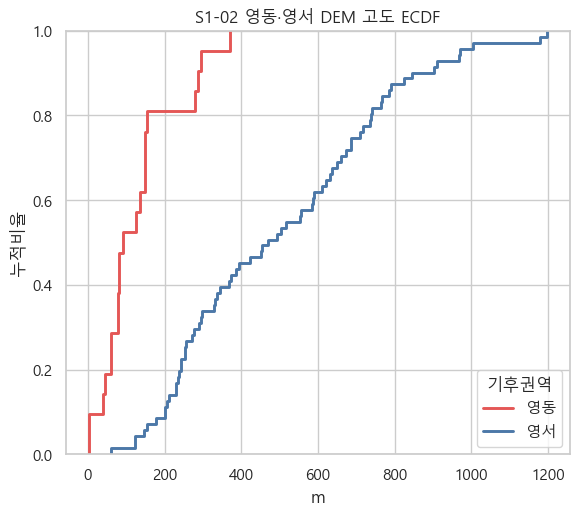

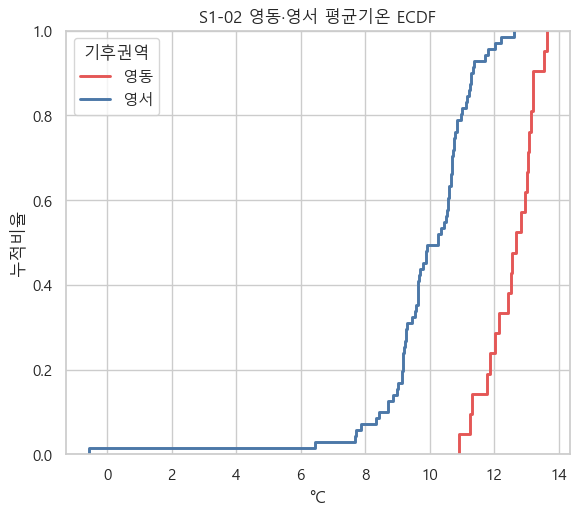

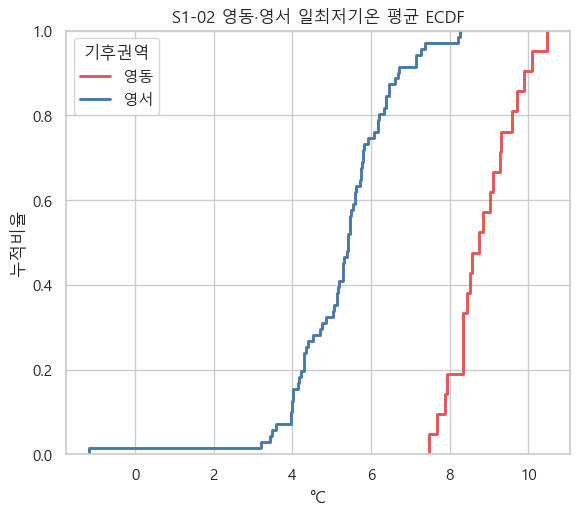

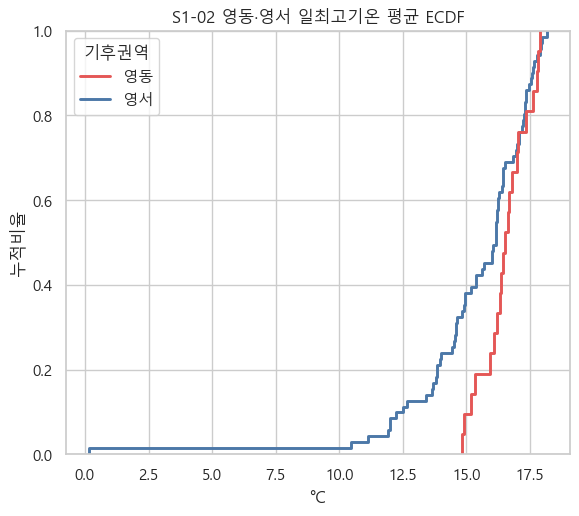

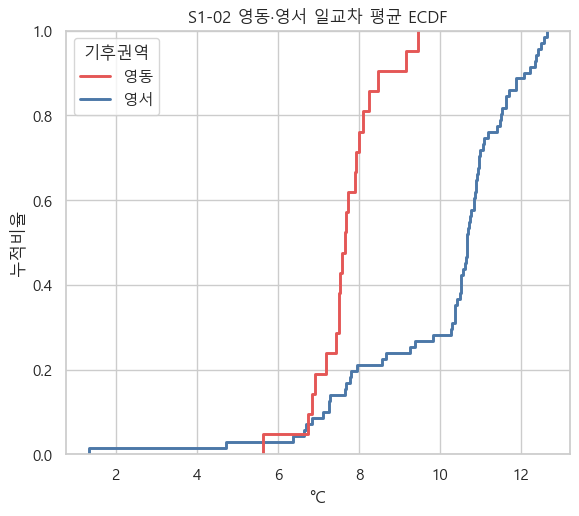

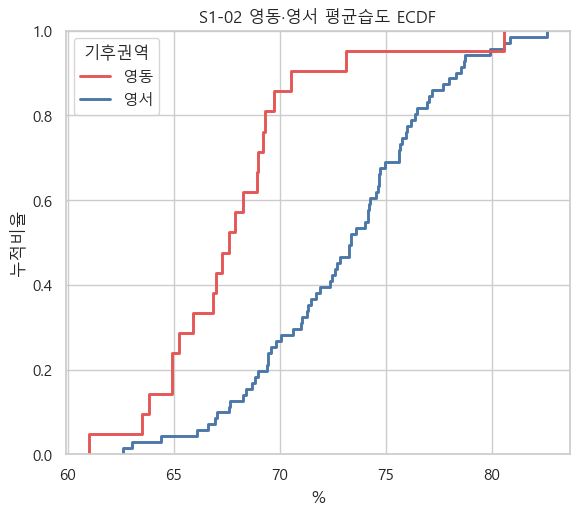

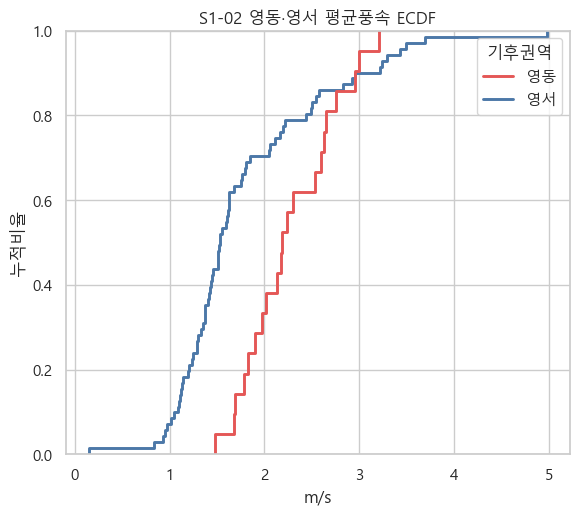

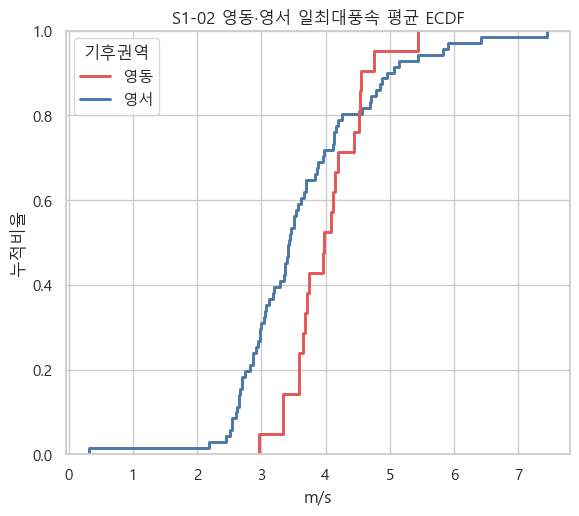

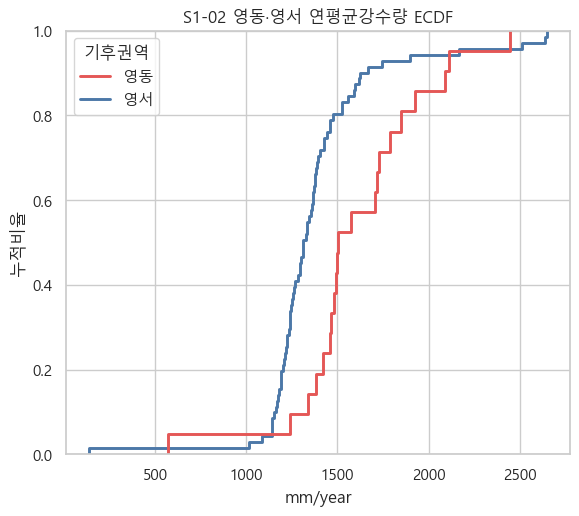

In [19]:
s102_ecdf_paths = []
for column, label, unit in VARIABLE_SPECS:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.ecdfplot(
        data=cell_climate,
        x=column,
        hue="기후권역",
        hue_order=REGION_ORDER,
        palette=REGION_PALETTE,
        linewidth=2.1,
        ax=ax,
    )
    ax.set_title(f"S1-02 영동·영서 {label} ECDF")
    ax.set_xlabel(unit)
    ax.set_ylabel("누적비율")
    path = PLOT_DIR / f"S1-02_ecdf_{column}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    s102_ecdf_paths.append(path)

## 18. S1-02 효과크기

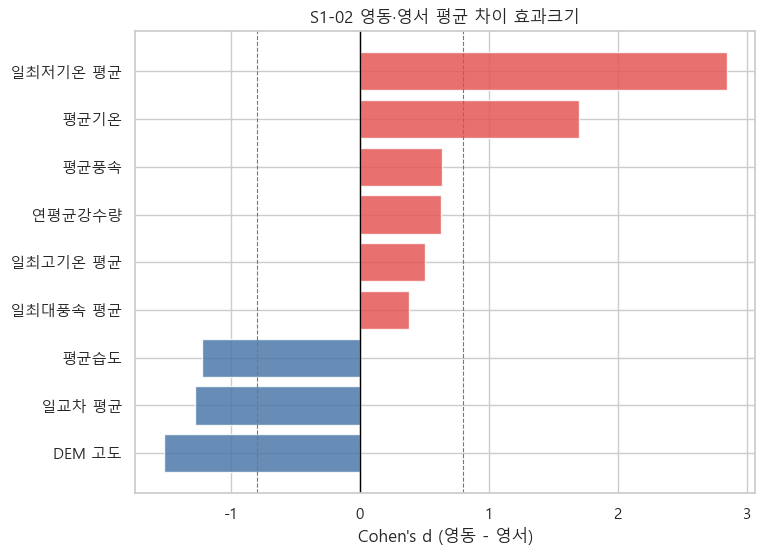

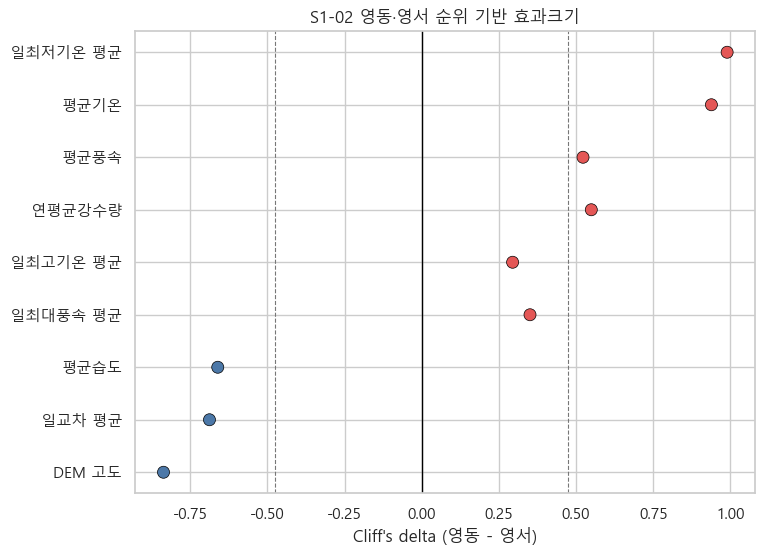

In [20]:
effect_plot = region_tests.sort_values("Cohen_d_영동_minus_영서").copy()
y_positions = np.arange(len(effect_plot))

fig, ax = plt.subplots(figsize=(8, 6))
cohen_values = effect_plot["Cohen_d_영동_minus_영서"]
ax.barh(
    y_positions,
    cohen_values,
    color=np.where(
        cohen_values >= 0,
        REGION_PALETTE["영동"],
        REGION_PALETTE["영서"],
    ),
    alpha=0.85,
)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(-0.8, color="#777777", linestyle="--", linewidth=0.8)
ax.axvline(0.8, color="#777777", linestyle="--", linewidth=0.8)
ax.set_yticks(y_positions, effect_plot["표시명"])
ax.set_xlabel("Cohen's d (영동 - 영서)")
ax.set_title("S1-02 영동·영서 평균 차이 효과크기")
s102_cohen_path = PLOT_DIR / "S1-02_effect_cohen_d.png"
fig.savefig(s102_cohen_path, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
cliff_values = effect_plot["Cliff_delta_영동_minus_영서"]
ax.scatter(
    cliff_values,
    y_positions,
    c=np.where(
        cliff_values >= 0,
        REGION_PALETTE["영동"],
        REGION_PALETTE["영서"],
    ),
    s=75,
    edgecolor="black",
    linewidth=0.5,
)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(-0.474, color="#777777", linestyle="--", linewidth=0.8)
ax.axvline(0.474, color="#777777", linestyle="--", linewidth=0.8)
ax.set_yticks(y_positions, effect_plot["표시명"])
ax.set_xlabel("Cliff's delta (영동 - 영서)")
ax.set_title("S1-02 영동·영서 순위 기반 효과크기")
s102_cliff_path = PLOT_DIR / "S1-02_effect_cliff_delta.png"
fig.savefig(s102_cliff_path, dpi=180, bbox_inches="tight")
plt.show()

## 19. S1-02 완료 검증

In [21]:
s102_plot_paths = [
    s102_region_map_path,
    s102_dem_map_path,
    *s102_box_paths,
    *s102_ecdf_paths,
    s102_cohen_path,
    s102_cliff_path,
]
s102_summary = pd.DataFrame({
    "지표": [
        "영동 셀 수",
        "영서 셀 수",
        "셀별 관측일수 최솟값",
        "셀별 관측일수 최댓값",
        "분석 변수 수",
        "Welch FDR 유의 변수 수",
        "Mann-Whitney FDR 유의 변수 수",
        "S1-02 결과표 수",
        "S1-02 개별 플롯 수",
    ],
    "값": [
        int((cell_climate["기후권역"] == "영동").sum()),
        int((cell_climate["기후권역"] == "영서").sum()),
        int(cell_climate["관측일수"].min()),
        int(cell_climate["관측일수"].max()),
        len(ANALYSIS_COLUMNS),
        int(region_tests["Welch_FDR_0.05"].sum()),
        int(region_tests["MannWhitney_FDR_0.05"].sum()),
        4,
        len(s102_plot_paths),
    ],
})
s102_summary.to_csv(
    TABLE_DIR / "S1-02_summary_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

assert len(cell_climate) == 92
assert int((cell_climate["기후권역"] == "영동").sum()) == 21
assert int((cell_climate["기후권역"] == "영서").sum()) == 71
assert cell_climate["관측일수"].min() == 731
assert cell_climate["관측일수"].max() == 731
assert cell_climate[ANALYSIS_COLUMNS].isna().sum().sum() == 0
assert len(region_tests) == len(ANALYSIS_COLUMNS)
assert np.isfinite(
    region_tests[
        [
            "Welch_p",
            "MannWhitney_p",
            "Cohen_d_영동_minus_영서",
            "Cliff_delta_영동_minus_영서",
        ]
    ].to_numpy()
).all()
for path in s102_plot_paths:
    assert path.exists() and path.stat().st_size > 0

display(s102_summary)
print("S1-02 validation passed")

,지표,값
0,영동 셀 수,21
1,영서 셀 수,71
2,셀별 관측일수 최솟값,731
3,셀별 관측일수 최댓값,731
4,분석 변수 수,9
5,Welch FDR 유의 변수 수,9
6,Mann-Whitney FDR 유의 변수 수,9
7,S1-02 결과표 수,4
8,S1-02 개별 플롯 수,22


S1-02 validation passed


## 20. 검토 반영 분석 모듈

S1-03 이후 분석은 반복관측 독립성, 이상 셀 민감도, 지수의 구성적 상관,
선행연구 단계의 제한적 의미를 반영한 검토 버전으로 실행한다.
결과 해석은 대응 진행예정로그에만 기록한다.

In [22]:
from step1_reviewed_analysis import (
    run_s103,
    run_s104,
    run_s105,
    run_s106,
    run_s107,
    run_s108,
    run_s109,
    run_s110,
    run_s1a01,
)

## 21. S1-03 상호배타적 계절 비교

In [23]:
s103 = run_s103(
    hourly_weather=hourly_weather,
    climate_type=climate_type,
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s103["paired_tests"])
display(s103["date_tests"])

,변수,N_셀,비산불기_평균,산불조심기간_평균,평균차_비산불기_minus_산불조심기간,평균차_CI95_하한,평균차_CI95_상한,Paired_t,Paired_p,Wilcoxon_W,Wilcoxon_p,Cohen_dz,Paired_q_FDR,Wilcoxon_q_FDR
0,기온_C,92,18.733146,4.581274,14.151873,13.749021,14.554724,69.779878,8.245276e-81,0.0,8.149782e-17,7.275055,4.122638e-80,8.422199e-17
1,최저기온_C,92,15.024625,-0.331169,15.355794,14.902015,15.809572,67.218692,2.323960e-79,0.0,8.149782e-17,7.008033,5.809900e-79,8.422199e-17
2,일교차_C,92,8.346976,10.342469,-1.995493,-2.109385,-1.881602,-34.803345,2.259691e-54,1.0,8.422199e-17,-3.628500,3.766151e-54,8.422199e-17
3,습도_pct,92,81.007517,65.170222,15.837295,14.733326,16.941263,28.496142,3.941858e-47,0.0,8.149782e-17,2.970928,4.927323e-47,8.422199e-17
4,풍속_m_s,92,1.594374,2.121961,-0.527587,-0.603642,-0.451533,-13.779419,5.410788e-24,1.0,8.422199e-17,-1.436604,5.410788e-24,8.422199e-17


,변수,N_날짜,영동_일평균,영서_일평균,평균차_영동_minus_영서,Paired_t,Paired_p,Wilcoxon_W,Wilcoxon_p,Cohen_dz,주의,Paired_q_FDR,Wilcoxon_q_FDR
0,기온_C,731,12.529596,9.906582,2.623014,35.434171,8.978715e-161,9287.0,2.496346e-105,1.310580,날짜 간 자기상관을 고려하지 않은 기술적 대응 비교,2.244679e-160,6.240864e-105
1,최저기온_C,731,8.833455,5.287415,3.546040,45.894201,2.477939e-217,180.0,5.249671e-121,1.697458,날짜 간 자기상관을 고려하지 않은 기술적 대응 비교,1.238969e-216,2.624835e-120
2,일교차_C,731,7.672266,10.049858,-2.377592,-28.290872,1.871239e-119,18127.0,3.638085e-91,-1.046376,날짜 간 자기상관을 고려하지 않은 기술적 대응 비교,2.339048e-119,4.547606e-91
3,습도_pct,731,67.837284,72.971795,-5.134512,-12.639267,2.952607e-33,72956.0,1.769274e-26,-0.467480,날짜 간 자기상관을 고려하지 않은 기술적 대응 비교,2.952607e-33,1.769274e-26
4,풍속_m_s,731,2.271843,1.791457,0.480386,31.425491,9.114327e-138,11699.0,2.316496e-101,1.162314,날짜 간 자기상관을 고려하지 않은 기술적 대응 비교,1.519054e-137,3.860827e-101


## 22. S1-04 군집 이상치·민감도·안정성 감사

In [24]:
s104 = run_s104(
    cell_climate=cell_climate,
    climate_type=climate_type,
    weather_grid=weather_grid,
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s104["quality_audit"].query("품질검토대상"))
display(s104["scores"])
display(s104["crosstab_k3"])
display(s104["stability"].describe())

,기상셀ID,평균기온_C_robust_z,평균_일교차_C_robust_z,평균습도_pct_robust_z,평균풍속_m_s_robust_z,연평균강수량_mm_robust_z,극단값_변수수,품질검토대상
91,YS_0071,-6.86928,-4.397475,1.753858,-2.309442,-6.212836,3,True


,데이터,K,N_셀,Silhouette,최소군집크기,군집크기,기존3유형_ARI
0,전체,2,92,0.368883,35,57|35,NaN
1,전체,3,92,0.381001,1,35|56|1,0.356696
2,전체,4,92,0.396688,1,54|25|12|1,NaN
3,품질검토대상제외,2,91,0.379471,35,56|35,NaN
4,품질검토대상제외,3,91,0.404973,12,54|25|12,0.429688
5,품질검토대상제외,4,91,0.398092,4,10|53|24|4,NaN


Cluster,0,1,2
기후지형유형,,,
고지·산간형,14,4,9
영동 해안형,1,20,0
영서 내륙형,39,1,3


,random_state,Silhouette,ARI_vs_seed42
count,20.00000,20.000000,20.000000
mean,9.50000,0.404973,0.994285
std,5.91608,0.000157,0.012065
min,0.00000,0.404381,0.967855
25%,4.75000,0.404973,1.000000
50%,9.50000,0.404973,1.000000
75%,14.25000,0.404973,1.000000
max,19.00000,0.405174,1.000000


## 23. S1-05 3개 기후지형유형 기술적 분리 재검증

In [25]:
s105 = run_s105(
    full_data=s104["data"],
    clean_data=s104["clean"],
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s105["global_tests"])
display(s105["pairwise"])

,데이터,변수,N_셀,H_stat,p_value,epsilon_squared,q_FDR
0,전체,DEM_고도_m,92,56.604951,5.109649e-13,0.622032,3.576754e-12
1,전체,평균기온_C,92,51.224873,7.527664e-12,0.562911,2.634682e-11
2,전체,평균_일최저기온_C,92,47.593741,4.625413e-11,0.523008,1.079263e-10
3,전체,평균_일교차_C,92,37.333585,7.818348e-09,0.410259,1.368211e-08
4,전체,평균습도_pct,92,22.114789,1.577010e-05,0.243020,1.839845e-05
5,전체,평균풍속_m_s,92,34.052483,4.032712e-08,0.374203,5.645797e-08
6,전체,연평균강수량_mm,92,15.683624,3.929563e-04,0.172348,3.929563e-04
7,품질검토대상제외,DEM_고도_m,91,56.258258,6.076795e-13,0.625092,4.253757e-12
8,품질검토대상제외,평균기온_C,91,52.068327,4.937492e-12,0.578537,1.728122e-11
9,품질검토대상제외,평균_일최저기온_C,91,47.637791,4.524650e-11,0.529309,1.055752e-10


,변수,그룹A,그룹B,A_N,B_N,A_중앙값,B_중앙값,MannWhitney_U,p_value,Cliff_delta_A_minus_B,Cohen_d_A_minus_B,q_FDR_global
0,DEM_고도_m,영동 해안형,고지·산간형,21,27,91.378746,708.671021,4.0,6.696614e-09,-0.985891,-3.691887,2.343815e-08
1,DEM_고도_m,영동 해안형,영서 내륙형,21,43,91.378746,297.275391,114.0,1.445763e-06,-0.747508,-1.334024,3.373448e-06
2,DEM_고도_m,고지·산간형,영서 내륙형,27,43,708.671021,297.275391,1049.0,1.636004e-08,0.807063,1.938834,4.908013e-08
3,평균기온_C,영동 해안형,고지·산간형,21,27,12.662717,9.262117,563.0,6.696614e-09,0.985891,3.571225,2.343815e-08
4,평균기온_C,영동 해안형,영서 내륙형,21,43,12.662717,10.664723,861.0,4.972765e-09,0.906977,2.049156,2.343815e-08
5,평균기온_C,고지·산간형,영서 내륙형,27,43,9.262117,10.664723,255.0,8.807705e-05,-0.560724,-0.949203,1.321156e-04
6,평균_일최저기온_C,영동 해안형,고지·산간형,21,27,8.740561,5.187114,563.0,6.696614e-09,0.985891,3.402276,2.343815e-08
7,평균_일최저기온_C,영동 해안형,영서 내륙형,21,43,8.740561,5.478782,899.0,1.643485e-10,0.991141,3.465099,3.451319e-09
8,평균_일최저기온_C,고지·산간형,영서 내륙형,27,43,5.187114,5.478782,487.0,2.618235e-01,-0.161068,-0.177418,2.950918e-01
9,평균_일교차_C,영동 해안형,고지·산간형,21,27,7.646772,9.374254,171.0,1.993030e-02,-0.396825,-0.869865,2.615852e-02


## 24. S1-06 월별 기후와 풍향 분포

In [26]:
s106 = run_s106(
    hourly_weather=hourly_weather,
    climate_type=climate_type,
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s106["monthly_summary"].head(18))
display(s106["monthly_tests"].head())

,기후지형유형,월,변수,N_셀,평균,표준편차,중앙값
0,고지·산간형,1,평균기온_C,27,-3.022801,1.940439,-3.497863
1,고지·산간형,1,일교차_C,27,8.684570,2.251519,8.648387
2,고지·산간형,1,평균상대습도_pct,27,65.747955,5.894816,66.744603
3,고지·산간형,1,일최대시간풍속_m_s,27,4.513751,1.323149,4.240323
4,고지·산간형,1,일강수량_mm,27,1.650185,0.475952,1.633710
5,고지·산간형,1,서풍계열_비율,27,0.342120,0.238905,0.329301
6,고지·산간형,2,평균기온_C,27,-0.179254,1.553413,-0.730351
7,고지·산간형,2,일교차_C,27,9.581222,2.219285,10.026667
8,고지·산간형,2,평균상대습도_pct,27,63.102514,4.892516,63.144488
9,고지·산간형,2,일최대시간풍속_m_s,27,4.920097,1.490231,4.729298


,월,변수,N_셀,H_stat,p_value,epsilon_squared,q_FDR_global
0,1,평균기온_C,92,44.757643,1.909859e-10,0.491842,1.238405e-09
1,1,일교차_C,92,38.830427,3.698962e-09,0.426708,1.210569e-08
2,1,평균상대습도_pct,92,41.856749,8.145588e-10,0.459964,3.258235e-09
3,1,일최대시간풍속_m_s,92,31.387363,1.528694e-07,0.344916,3.144743e-07
4,1,일강수량_mm,92,26.610610,1.665634e-06,0.292424,2.607079e-06


## 25. S1-07 고도 연관성·층화·비선형 민감도

In [27]:
s107 = run_s107(
    full_data=s104["data"],
    clean_data=s104["clean"],
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s107["correlations"])
display(s107["nonlinear"])

,데이터,층,변수,N_셀,Spearman_rho,p_value,q_FDR_global
0,전체,전체권역,평균기온_C,92,-0.788558,1.047627e-20,1.571440e-19
1,전체,전체권역,평균_일최저기온_C,92,-0.617018,5.769309e-11,4.326981e-10
2,전체,전체권역,평균_일교차_C,92,-0.004994,9.623201e-01,9.910847e-01
3,전체,전체권역,평균습도_pct,92,0.368402,3.024118e-04,1.296051e-03
4,전체,전체권역,평균풍속_m_s,92,0.131791,2.104670e-01,3.577006e-01
5,전체,전체권역,연평균강수량_mm,92,-0.134704,2.004700e-01,3.577006e-01
6,품질검토대상제외,전체권역,평균기온_C,91,-0.812709,1.368578e-22,4.105734e-21
7,품질검토대상제외,전체권역,평균_일최저기온_C,91,-0.636646,1.177746e-11,1.177746e-10
8,품질검토대상제외,전체권역,평균_일교차_C,91,-0.017009,8.728615e-01,9.910847e-01
9,품질검토대상제외,전체권역,평균습도_pct,91,0.382672,1.814432e-04,9.072158e-04


,변수,선형_R2,이차_R2,이차_minus_선형_R2,이차항계수
0,평균기온_C,0.605150,0.642781,0.037630,0.000003
1,평균_일최저기온_C,0.345821,0.495979,0.150158,0.000008
2,평균_일교차_C,0.012528,0.259218,0.246690,-0.000011
3,평균습도_pct,0.091130,0.167660,0.076530,-0.000014
4,평균풍속_m_s,0.105096,0.300816,0.195720,0.000004
5,연평균강수량_mm,0.002299,0.076400,0.074101,0.001032


## 26. S1-08 셀 단위 캐나다 지수 배경 분포

In [28]:
s108 = run_s108(
    canadian_indices=canadian_indices,
    climate_type=climate_type,
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s108["regional_tests"])
display(s108["season_summary"].head(24))
display(s108["season_tests"])

,FWI지수,N_셀,H_stat,p_value,epsilon_squared,q_FDR
0,FFMC,92,5.950976,0.051023,0.065395,0.051023
1,DMC,92,18.462876,0.000098,0.202889,0.000147
2,DC,92,11.046645,0.003993,0.121392,0.004791
3,ISI,92,21.672594,0.000020,0.238160,0.000059
4,BUI,92,19.612150,0.000055,0.215518,0.000110
5,FWI,92,22.041986,0.000016,0.242220,0.000059


,기후지형유형,계절,FWI지수,N_셀,평균,표준편차,중앙값
0,고지·산간형,가을,FFMC,27,71.754805,3.281162,71.467864
1,고지·산간형,가을,DMC,27,14.031867,3.651015,14.373862
2,고지·산간형,가을,DC,27,65.734672,20.177376,63.296153
3,고지·산간형,가을,ISI,27,2.916030,0.628082,2.731777
4,고지·산간형,가을,BUI,27,17.464027,4.617973,17.440470
5,고지·산간형,가을,FWI,27,4.779440,1.222725,4.581106
6,고지·산간형,겨울,FFMC,27,76.283092,2.470138,76.508423
7,고지·산간형,겨울,DMC,27,10.273832,5.705232,8.088602
8,고지·산간형,겨울,DC,27,71.878388,21.643977,75.884583
9,고지·산간형,겨울,ISI,27,3.292049,1.113752,3.153620


,기후지형유형,FWI지수,N_셀,Friedman_chi2,p_value,Kendall_W,q_FDR_global
0,영동 해안형,FFMC,21,57.057143,2.498704e-12,0.905669,4.088788e-12
1,영동 해안형,DMC,21,41.685714,4.678027e-09,0.661678,5.613633e-09
2,영동 해안형,DC,21,60.657143,4.254421e-13,0.962812,8.508842e-13
3,영동 해안형,ISI,21,54.885714,7.262653e-12,0.871202,1.089398e-11
4,영동 해안형,BUI,21,51.914286,3.123747e-11,0.824036,4.016246e-11
5,영동 해안형,FWI,21,58.600000,1.170282e-12,0.930159,2.106508e-12
6,고지·산간형,FFMC,27,71.400000,2.140109e-15,0.881481,5.503136e-15
7,고지·산간형,DMC,27,19.044444,2.676743e-04,0.235117,2.676743e-04
8,고지·산간형,DC,27,63.488889,1.055693e-13,0.783813,2.375309e-13
9,고지·산간형,ISI,27,52.377778,2.488226e-11,0.646639,3.445236e-11


## 27. S1-09 FFMC 10일평균과 선행연구 단계

In [29]:
s109 = run_s109(
    canadian_data=s108["data"],
    weather_grid=weather_grid,
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s109["ffmc10_summary"])
display(s109["crosstab"].round(1))

,기후지형유형,계절,N_셀,평균,표준편차,중앙값
0,고지·산간형,가을,27,70.676394,3.260643,70.164575
1,고지·산간형,겨울,27,77.064697,2.419886,77.277471
2,고지·산간형,봄,27,73.336393,2.631108,73.554008
3,고지·산간형,여름,27,65.073991,3.837536,65.534148
4,영동 해안형,가을,21,73.075790,3.050933,74.079770
5,영동 해안형,겨울,21,80.447209,2.570008,80.376466
6,영동 해안형,봄,21,73.972400,3.075636,74.425509
7,영동 해안형,여름,21,65.889867,4.375857,66.911757
8,영서 내륙형,가을,44,72.945995,3.162245,73.958516
9,영서 내륙형,겨울,44,76.503733,2.195660,76.863674


선행연구단계      1단계   2단계   3단계   4단계
기후지형유형 계절                        
고지·산간형 가을  21.6  24.5  18.6  35.3
       겨울   6.1  17.6  23.4  53.0
       봄    8.9  25.8  36.0  29.4
       여름  29.2  26.5  22.0  22.3
영동 해안형 가을  16.8  24.4  17.8  41.0
       겨울   3.5  14.8  19.5  62.2
       봄    9.3  20.6  38.9  31.2
       여름  28.2  26.3  22.5  23.0
영서 내륙형 가을  15.2  22.6  23.2  39.0
       겨울   6.7  16.6  25.9  50.8
       봄   11.3  21.4  29.2  38.1
       여름  23.0  23.9  27.7  25.4

## 28. S1-10 지수 구성 정합성과 층화 상관

In [30]:
s110 = run_s110(
    canadian_data=s108["data"],
    table_dir=TABLE_DIR,
    plot_dir=PLOT_DIR,
)
display(s110["construction"])
display(s110["cross_corr"].round(2))
display(
    s110["stratified"].query(
        "기상변수 == '기온_C' and FWI지수 == 'FWI'"
    )
)

,지수,직접입력,해석
0,FFMC,"기온, 습도, 풍속, 직전24시간 강수",산식 입력과 출력의 방향성 점검
1,DMC,"기온, 습도, 직전24시간 강수, 월",산식 입력과 출력의 방향성 점검
2,DC,"기온, 직전24시간 강수, 월",산식 입력과 출력의 방향성 점검
3,ISI,"FFMC, 풍속",구성요소 관계 점검
4,BUI,"DMC, DC",구성요소 관계 점검
5,FWI,"ISI, BUI",구성요소 관계 점검


,FFMC,DMC,DC,ISI,BUI,FWI
기온_C,0.01,0.18,0.13,-0.04,0.19,0.05
습도_pct,-0.70,-0.39,-0.10,-0.71,-0.33,-0.64
풍속_km_h,0.14,0.10,-0.04,0.34,0.08,0.26
강수량_mm,-0.68,-0.34,-0.20,-0.66,-0.32,-0.62


,기후지형유형,계절,기상변수,FWI지수,N_셀일,Spearman_rho,p_value,q_FDR_global
5,고지·산간형,가을,기온_C,FWI,4914,-0.298664,8.370237e-102,1.401528e-101
29,고지·산간형,겨울,기온_C,FWI,4887,0.028456,4.668067e-02,4.979272e-02
53,고지·산간형,봄,기온_C,FWI,4968,0.455476,4.644027e-253,1.238407e-252
77,고지·산간형,여름,기온_C,FWI,4968,0.469628,4.908435e-271,1.359259e-270
101,영동 해안형,가을,기온_C,FWI,3822,-0.421942,7.166636e-165,1.495646e-164
125,영동 해안형,겨울,기온_C,FWI,3801,-0.050181,1.969925e-03,2.132851e-03
149,영동 해안형,봄,기온_C,FWI,3864,0.448376,1.703931e-190,3.833844e-190
173,영동 해안형,여름,기온_C,FWI,3864,0.296061,5.082713e-79,7.955551e-79
197,영서 내륙형,가을,기온_C,FWI,8008,-0.059399,1.041468e-07,1.190250e-07
221,영서 내륙형,겨울,기온_C,FWI,7964,0.015977,1.539748e-01,1.618421e-01


## 29. S1-A01 품질검토대상 셀 원천 요약

In [31]:
s1a01 = run_s1a01(
    hourly_weather=hourly_weather,
    full_data=s104["data"],
    quality_flag_ids=s104["quality_flag_ids"],
    table_dir=TABLE_DIR,
)
display(s1a01)

,기상셀ID,연도,연평균기온_C,연평균습도_pct,연평균풍속_m_s,연강수량_mm,연평균기온_C_백분위,연평균습도_pct_백분위,연평균풍속_m_s_백분위,연강수량_mm_백분위,기후지형유형,대표지점명,DEM_고도_m,극단값_변수수,처리원칙
0,YS_0071,2020.5,-0.567031,80.842475,0.149971,137.645,0.01087,0.98913,0.01087,0.01087,영서 내륙형,시동,251.958511,3,원천 보정 전 자동 제거 금지; 전체 포함 결과와 품질검토대상 제외 민감도 결과 병기


## 30. 수정 분석 완료 검증

In [32]:
required_tables = [
    "S1-03_fire_vs_nonfire_paired_tests.csv",
    "S1-04_cluster_sensitivity_scores.csv",
    "S1-04_k3_seed_stability.csv",
    "S1-05_kruskal_sensitivity.csv",
    "S1-06_monthly_type_tests.csv",
    "S1-07_altitude_spearman_sensitivity.csv",
    "S1-08_fwi_cell_level_kruskal.csv",
    "S1-09_ffmc10_season_cell_summary.csv",
    "S1-10_weather_fwi_stratified_spearman.csv",
    "S1-A01_flagged_cell_source_audit.csv",
]
missing_tables = [
    name for name in required_tables if not (TABLE_DIR / name).exists()
]
assert not missing_tables, missing_tables
assert len(s103["paired_tests"]) == 5
assert len(s104["clean"]) < len(s104["data"])
assert s108["regional_tests"]["N_셀"].eq(92).all()
assert set(s109["crosstab"].columns) == {
    "1단계", "2단계", "3단계", "4단계"
}
print("Reviewed S1-03 through S1-10 and S1-A01 validation passed")

Reviewed S1-03 through S1-10 and S1-A01 validation passed
